# Target trial emulation with k-nearest neighbours matching

In this notebook synthetic data is generated with treatment ('thrombolysis') in stroke.

k-nearest-neighbours (knn) is used to find closely matching control patients for each treated patient. This creates a pseudo-randomised clinical trial.

## Method

### Standardisation

In order to put all features on equivalent scales the data is *standardised* (all points are expressed as the number of standard deviations away from the mean for each feature).  

$$z = \frac{x - \mu}{\sigma}$$

Where: 

- *z* = The standard score (Z-score)
- *x* = Raw data point value
- *$\mu$ (mu)* = The mean of the population
- *$\sigma$ (sigma)* = The standard deviation of the population

### Finding nearest neighbours

knn measures the distance to other points in the data set. A number of ways may be used to calculate distance (see below). The Euclidian distance is the most common method. 

![](_images/distance.jpg)


**Euclidian** distance:

$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

**Manhattan** distance:

$d = |x_2 - x_1| + |y_2 - y_1|$

**Minkowski** distance:

$d = \left( |x_2 - x_1|^p + |y_2 - y_1|^p \right)^{1/p}$

You should match on all significant features - those that affect outcome directly and those that affect the likelihood that someone receives treatment.

### Statistical tests

Once we have created our matched populations we compare the treated and matched control populations. Ideally we should see no significant differences in all of the features used to match the populations. We will perform statistical tests - a *t-test* for features that are on a continuos scale, and a Chi-squared test for binary features.



## Import packages

In [1]:
# Standard packages
import pandas as pd
import numpy as np

# K-nearest Neighbors
from sklearn.neighbors import NearestNeighbors

# Standardisation
from sklearn.preprocessing import StandardScaler

# Statistical tests
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# Synthetic data generation (local module)
from modules.create_data import create_stroke_data
from modules.create_data import draw_dag

## Matching function

Matches on standardised data.

In [2]:
def get_knn_matches(df_treated, df_untreated, match_columns, k=1):
    """
    Finds k nearest untreated patients for each treated patient based on 
    standardized columns, returning the original untreated dataframe rows.

    Inputs:
    - df_treated: DataFrame of treated patients
    - df_untreated: DataFrame of untreated patients
    - match_columns: List of column names to use for matching
    - k: Number of nearest neighbors to find for each treated patient
    """
    
    # 1. Isolate the specific columns to match on
    treated_features = df_treated[match_columns]
    untreated_features = df_untreated[match_columns]
    
    # 2. Standardize the data
    # We fit the scaler on the treated pool to establish the baseline scale,
    # then transform both dataframes to that same scale ().
    
    # Fit scaler
    scaler = StandardScaler()
    scaler.fit(treated_features)

    # Transform (standardize) both treated and untreated features
    X_treated_scaled = scaler.transform(treated_features)
    X_untreated_scaled = scaler.transform(untreated_features)
    
    # 3. Fit Nearest Neighbors on the standardized untreated pool
    nn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nn.fit(X_untreated_scaled)
    
    # 4. Query the model to find the k nearest neighbors for each treated patient
    distances, indices = nn.kneighbors(X_treated_scaled)
    
    # 5. Extract the matched untreated patients using the original unscaled data
    # Flatten the 2D indices array to a 1D array so we can slice the dataframe
    matched_indices = indices.flatten()
    df_matched_controls = df_untreated.iloc[matched_indices].copy()
    
    # 6. Add tracking columns
    # Track which treated patient index this control was matched to, and how far apart they were
    df_matched_controls['matched_to_treated_index'] = np.repeat(df_treated.index, k)
    df_matched_controls['knn_distance'] = distances.flatten()
    
    return df_matched_controls

## Create synthetic data

Use the create_stroke_data to create a synthetic batch of data.

### Show relationships used to create data

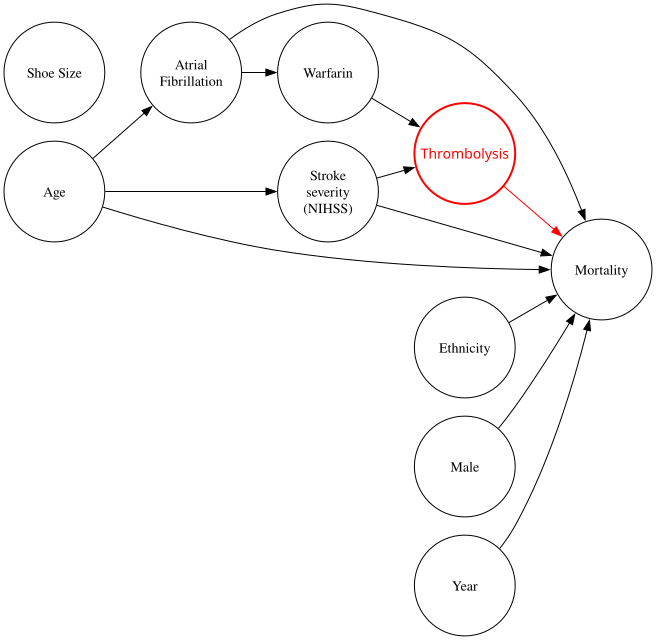

In [3]:
dag = draw_dag()
dag

### Create synthetic data

In [4]:
df = create_stroke_data(n=5000, seed=42)
df

,patient_id,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,...,mortality_odds_no_treatment,mortality_log_odds_no_treatment,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died
0,1,2021,66,white,1,0,0,9,14,312.0,...,0.3699,-0.9946,0.2210,0.2837,-1.2598,1.3036,0.2651,0.0490,0.2210,0
1,2,2020,79,white,0,0,0,6,16,148.0,...,0.6807,-0.3847,0.1729,0.2090,-1.5652,3.2561,1.1805,0.2321,0.1729,0
2,3,2019,88,asian,1,0,0,12,9,90.0,...,0.6129,-0.4895,0.2247,0.2898,-1.2386,2.1150,0.7490,0.1553,0.2247,0
3,4,2023,74,white,1,0,0,10,11,99999.0,...,0.3889,-0.9445,0.2800,0.3889,-0.9445,1.0000,0.0000,0.0000,0.2800,0
4,5,2023,70,white,1,0,0,7,8,99999.0,...,0.2987,-1.2083,0.2300,0.2987,-1.2083,1.0000,0.0000,0.0000,0.2300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2018,72,asian,0,0,0,7,8,99999.0,...,0.3158,-1.1527,0.2400,0.3158,-1.1527,1.0000,0.0000,0.0000,0.2400,1
4996,4997,2024,63,asian,0,0,0,8,28,99999.0,...,0.6529,-0.4263,0.3950,0.6529,-0.4263,1.0000,0.0000,0.0000,0.3950,1
4997,4998,2020,61,asian,1,0,0,11,16,99999.0,...,0.7094,-0.3433,0.4150,0.7094,-0.3433,1.0000,0.0000,0.0000,0.4150,0
4998,4999,2023,75,white,0,1,1,7,18,99999.0,...,0.4815,-0.7309,0.3250,0.4815,-0.7309,1.0000,0.0000,0.0000,0.3250,0


## Match data for thrombolysis vs no thrombolysis

In [5]:
treated = df[df['thrombolysis'] == 1]
untreated = df[df['thrombolysis'] == 0]

In [6]:
fields_to_match = [
    'age',
    'male',
    'afib',
    'warfarin',
    'nihss',
]

Find a control for each treated patient.

In [7]:
matched_controls = get_knn_matches(treated, untreated, fields_to_match, k=1)

In [8]:
matched_controls

,patient_id,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,...,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died,matched_to_treated_index,knn_distance
731,732,2018,66,white,1,0,0,5,14,99999.0,...,0.270,0.3699,-0.9946,1.0,0.0,0.0,0.270,0,0,0.000000
1296,1297,2022,79,asian,0,0,0,8,16,99999.0,...,0.355,0.5504,-0.5971,1.0,0.0,0.0,0.355,0,1,0.000000
101,102,2024,89,white,1,0,0,9,9,99999.0,...,0.335,0.5038,-0.6857,1.0,0.0,0.0,0.335,0,2,0.111586
1932,1933,2023,66,white,0,0,0,8,17,99999.0,...,0.250,0.3333,-1.0986,1.0,0.0,0.0,0.250,0,5,0.111586
4600,4601,2021,81,white,1,1,0,10,14,99999.0,...,0.365,0.5748,-0.5537,1.0,0.0,0.0,0.365,0,7,0.111586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1916,1917,2018,68,white,0,0,0,8,14,99999.0,...,0.230,0.2987,-1.2083,1.0,0.0,0.0,0.230,0,4988,0.000000
2165,2166,2023,68,white,0,0,0,10,9,99999.0,...,0.180,0.2195,-1.5163,1.0,0.0,0.0,0.180,1,4991,0.000000
2430,2431,2021,77,white,0,0,0,10,11,99999.0,...,0.245,0.3245,-1.1255,1.0,0.0,0.0,0.245,0,4993,0.000000
1082,1083,2019,64,asian,0,0,0,6,25,99999.0,...,0.370,0.5873,-0.5322,1.0,0.0,0.0,0.370,1,4994,0.000000


Show standardised distance.

In [9]:
matched_controls['knn_distance'].describe().round(3)

count    1690.000
mean        0.033
std         0.065
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.395
Name: knn_distance, dtype: float64

## Compare treated and matched controls

In [10]:
# Columns used when comparing treated patients with matched controls.
fields_to_describe = [
    'age',
    'male',
    'afib',
    'warfarin',
    'nihss',
    'thrombolysis_time',
    'thrombolysis',
]

# Categorical columns are removed before adding one-hot encoded values.
categorical_fields = ['ethnicity']

# Create copies so the original dataframes remain unchanged.
matched_controls_onehot = matched_controls.drop(
    columns=categorical_fields
).copy()
treated_onehot = treated.drop(columns=categorical_fields).copy()

# Store the names of all generated dummy columns.
onehot_columns = []

for field in categorical_fields:
    # Combine both groups so they use identical categories.
    combined = pd.concat([
        matched_controls[field],
        treated[field],
    ])

    # Generate dummy columns for every category.
    all_dummies = pd.get_dummies(
        combined,
        prefix=field,
        dtype=int,
    )
    dummy_columns = all_dummies.columns.tolist()
    onehot_columns.extend(dummy_columns)

    # Encode controls and align them with the combined categories.
    control_dummies = pd.get_dummies(
        matched_controls[field],
        prefix=field,
        dtype=int,
    ).reindex(columns=dummy_columns, fill_value=0)

    # Encode treated patients using the same dummy columns.
    treated_dummies = pd.get_dummies(
        treated[field],
        prefix=field,
        dtype=int,
    ).reindex(columns=dummy_columns, fill_value=0)

    # Append the encoded columns to each dataframe.
    matched_controls_onehot = pd.concat(
        [matched_controls_onehot, control_dummies],
        axis=1,
    )
    treated_onehot = pd.concat(
        [treated_onehot, treated_dummies],
        axis=1,
    )

# Include the one-hot columns and outcome in summary statistics.
fields_to_describe_one_hot = (
    fields_to_describe + onehot_columns + ['died']
)

In [11]:
matched_controls_onehot[fields_to_describe_one_hot].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
age,1690.0,74.323,8.970,60.0,66.0,74.0,82.0,89.0
male,1690.0,0.486,0.500,0.0,0.0,0.0,1.0,1.0
afib,1690.0,0.095,0.294,0.0,0.0,0.0,0.0,1.0
warfarin,1690.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0
nihss,1690.0,15.038,4.736,6.0,11.0,15.0,19.0,29.0
thrombolysis_time,1690.0,99999.000,0.000,99999.0,99999.0,99999.0,99999.0,99999.0
thrombolysis,1690.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0
ethnicity_asian,1690.0,0.198,0.398,0.0,0.0,0.0,0.0,1.0
ethnicity_black,1690.0,0.078,0.267,0.0,0.0,0.0,0.0,1.0
ethnicity_white,1690.0,0.725,0.447,0.0,0.0,1.0,1.0,1.0


In [12]:
treated_onehot[fields_to_describe_one_hot].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
age,1690.0,74.331,8.964,60.0,66.00,74.0,82.0,89.0
male,1690.0,0.486,0.500,0.0,0.00,0.0,1.0,1.0
afib,1690.0,0.095,0.294,0.0,0.00,0.0,0.0,1.0
warfarin,1690.0,0.000,0.000,0.0,0.00,0.0,0.0,0.0
nihss,1690.0,15.040,4.753,6.0,11.00,15.0,19.0,29.0
thrombolysis_time,1690.0,197.292,94.686,30.0,116.25,195.0,281.0,360.0
thrombolysis,1690.0,1.000,0.000,1.0,1.00,1.0,1.0,1.0
ethnicity_asian,1690.0,0.186,0.390,0.0,0.00,0.0,0.0,1.0
ethnicity_black,1690.0,0.101,0.301,0.0,0.00,0.0,0.0,1.0
ethnicity_white,1690.0,0.713,0.452,0.0,0.00,1.0,1.0,1.0


In [13]:
summary_rows = []

for field in fields_to_describe_one_hot:
    treated_values = treated_onehot[field]
    control_values = matched_controls_onehot[field]

    summary_rows.append({
        'field': field,
        'treated_mean': treated_values.mean(),
        'treated_std': treated_values.std(),
        'control_mean': control_values.mean(),
        'control_std': control_values.std(),
    })

summary_stats = pd.DataFrame(summary_rows)

summary_stats


,field,treated_mean,treated_std,control_mean,control_std
0,age,74.331361,8.964321,74.323077,8.970170
1,male,0.485799,0.499946,0.485799,0.499946
2,afib,0.095266,0.293669,0.095266,0.293669
3,warfarin,0.000000,0.000000,0.000000,0.000000
4,nihss,15.040237,4.752941,15.037870,4.735614
5,thrombolysis_time,197.291716,94.686330,99999.000000,0.000000
6,thrombolysis,1.000000,0.000000,0.000000,0.000000
7,ethnicity_asian,0.186391,0.389537,0.197633,0.398332
8,ethnicity_black,0.100592,0.300876,0.077515,0.267486
9,ethnicity_white,0.713018,0.452487,0.724852,0.446721


## Test differences

Use t-test for continuous variables and chi-squared for binary.

In [14]:
t_test_columns = ['age']

chi_squared_columns = [
    field for field in fields_to_describe_one_hot
    if field not in t_test_columns
]

p_values = []
statistical_results = {}

for field in fields_to_describe_one_hot:
    treated_values = treated_onehot[field].dropna()
    control_values = matched_controls_onehot[field].dropna()

    if field in t_test_columns:
        statistic, p_value = ttest_ind(
            treated_values,
            control_values,
            equal_var=False,
        )
        test_name = "t-test"

    else:
        # Reset indices to avoid duplicate-index reindexing errors.
        values = pd.concat(
            [treated_values.reset_index(drop=True),
             control_values.reset_index(drop=True)],
            ignore_index=True,
        )

        groups = pd.Series(
            ['treated'] * len(treated_values)
            + ['matched_control'] * len(control_values)
        )

        contingency_table = pd.crosstab(groups, values)

        # Constant variables have no difference to test.
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            statistic = 0.0
            p_value = 1.0
        else:
            statistic, p_value, _, _ = chi2_contingency(
                contingency_table
            )

        test_name = "chi-squared"

    p_values.append((field, p_value))

    statistical_results[field] = {
        'test': test_name,
        'statistic': statistic,
        'p_value': p_value,
    }

# Assign one p-value per row, rather than the final scalar p_value.
summary_stats['p-value'] = [p_value for _, p_value in p_values]

summary_stats.round(3)

,field,treated_mean,treated_std,control_mean,control_std,p-value
0,age,74.331,8.964,74.323,8.970,0.979
1,male,0.486,0.500,0.486,0.500,1.000
2,afib,0.095,0.294,0.095,0.294,1.000
3,warfarin,0.000,0.000,0.000,0.000,1.000
4,nihss,15.040,4.753,15.038,4.736,1.000
5,thrombolysis_time,197.292,94.686,99999.000,0.000,0.000
6,thrombolysis,1.000,0.000,0.000,0.000,0.000
7,ethnicity_asian,0.186,0.390,0.198,0.398,0.432
8,ethnicity_black,0.101,0.301,0.078,0.267,0.022
9,ethnicity_white,0.713,0.452,0.725,0.447,0.467


In [15]:
# Show full details fo t-test for died outcome
treated_values = treated_onehot['died'].dropna()
control_values = matched_controls_onehot['died'].dropna()

t_test = ttest_ind(treated_values, control_values)
print(f"t-statistic: {t_test.statistic}, p-value: {t_test.pvalue}")

t-statistic: -8.00142133784545, p-value: 1.6750421919026366e-15
